# 03_集成算法-Boosting算法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今儿和大家分享的是一个非常重要的算法模型：Boosting ！

Boosting是机器学习中用于提高模型的准确性。通过将多个弱分类器（即单个效果不好但可以改进的模型）组合成一个强分类器（即效果较好的模型），从而提高整体预测性能。

**Boosting的核心思想是逐步训练弱分类器，每个新分类器都重点关注前一个分类器错误预测的样本。最终，这些弱分类器的加权组合会产生一个强大的预测模型。**

给大家举一个简单的例子，相信大家很快就能大概理解\~

当你在玩一个游戏，游戏规则是你需要逐渐变得更好。你先用一个简单的策略去玩，这个策略可能不是特别聪明，只能处理一部分问题。然后你根据这次游戏的经验，找到自己做得不好的地方，调整策略，再试一次。每次你都这样调整策略，逐渐变得越来越好。最后，你将这些调整后的策略结合起来，就能赢得更多的游戏。

在Boosting中，我们先用一个简单的模型（弱分类器）来进行预测，然后根据这个模型的错误，调整并训练下一个模型。每个新的模型都专注于前一个模型做错的地方。这样，我们把多个“学得不够好”的模型（弱分类器）通过不断改进，结合成一个“学得特别好”的模型（强分类器），从而让最终的预测效果变得更准确。

## 理论基础

### 1. 初始化权重

设训练集为 $\{(x_i, y_i)\}_{i=1}^N$，其中 $x_i \in \mathbb{R}^d$ 为特征向量，$y_i \in \{-1, +1\}$ 为类别标签。

**样本权重初始化**：

初始时，所有样本的权重相等：


$$
w_i^{(1)} = \frac{1}{N} \quad \text{for } i = 1, 2, \ldots, N
$$


其中，$w_i^{(1)}$ 是第 $i$ 个样本在第 1 轮的权重。

### 2. 迭代训练弱分类器

对于每一轮 $t = 1, 2, \ldots, T$：

**a. 训练弱分类器**

使用加权样本 $\{(x_i, y_i, w_i^{(t)})\}$来训练弱分类器 $h_t(x)$。这个弱分类器可以是一个简单的决策树桩（即深度为 1 的决策树），但也可以是其他类型的分类器。

**目标**，最小化加权错误率（加权损失函数）：


$$
\epsilon_t = \frac{\sum_{i=1}^N w_i^{(t)} \cdot \mathbb{I}(h_t(x_i) \neq y_i)}{\sum_{i=1}^N w_i^{(t)}}
$$


其中，$\mathbb{I}(\cdot)$ 是指示函数，当 $h_t(x_i) \neq y_i$ 时取值为 1，否则为 0。

**b. 计算分类器的权重**

根据分类器的误差 $\epsilon_t$，计算其权重 $\alpha_t$：


$$
\alpha_t = \frac{1}{2} \ln \left(\frac{1 - \epsilon_t}{\epsilon_t}\right)
$$


$\alpha_t$ 衡量了分类器的可靠性。错误率 $\epsilon_t$ 越小，$\alpha_t$ 越大，表明该分类器的贡献越大。

**c. 更新样本权重**

更新每个样本的权重 $w_i^{(t+1)}$：


$$
w_i^{(t+1)} = w_i^{(t)} \cdot \exp(\alpha_t \cdot \mathbb{I}(h_t(x_i) \neq y_i))
$$


这个公式的作用是增加那些被当前分类器错误分类的样本的权重，从而使得下一轮的分类器更加关注这些难以分类的样本。

**归一化**：

对更新后的权重进行归一化，使得所有样本的权重之和为 1：


$$
w_i^{(t+1)} = \frac{w_i^{(t+1)}}{\sum_{j=1}^N w_j^{(t+1)}}
$$


### 3. 构建最终模型

**a. 强分类器**

**组合多个弱分类器**：将所有弱分类器 $h_t(x)$ 和它们的权重 $\alpha_t$ 组合成最终的强分类器 $H(x)$：


$$
H(x) = \text{sign}\left(\sum_{t=1}^T \alpha_t h_t(x)\right)
$$


这里，$\text{sign}(\cdot)$ 是符号函数，表示将线性组合的结果转化为最终的分类标签。

整体来说，Boosting算法通过迭代的方式逐步改进分类器的性能，每一轮都通过样本权重调整和误差修正来提高模型的精度。

主要步骤：

1. **初始化**：设置样本权重。
2. **迭代**：

   - 训练一个弱分类器。
   - 计算弱分类器的权重。
   - 更新样本权重，使得下一个分类器更关注之前错误分类的样本。
3. **组合**：将所有弱分类器按照其权重进行加权组合，形成最终的强分类器。

这种方法的核心在于每轮迭代中的错误修正和权重调整，使得最终模型能够对训练数据进行高效的分类。

## 完整案例

这里我们使用虚拟数据集应用Boosting算法进行分类，我们使用 `AdaBoost`（一个经典的Boosting算法）。

主要步骤包括：

1. 生成虚拟数据集。
2. 应用AdaBoost算法进行分类。
3. 绘制训练数据和预测结果的图形。
4. 绘制特征重要性图形。

Accuracy: 0.88


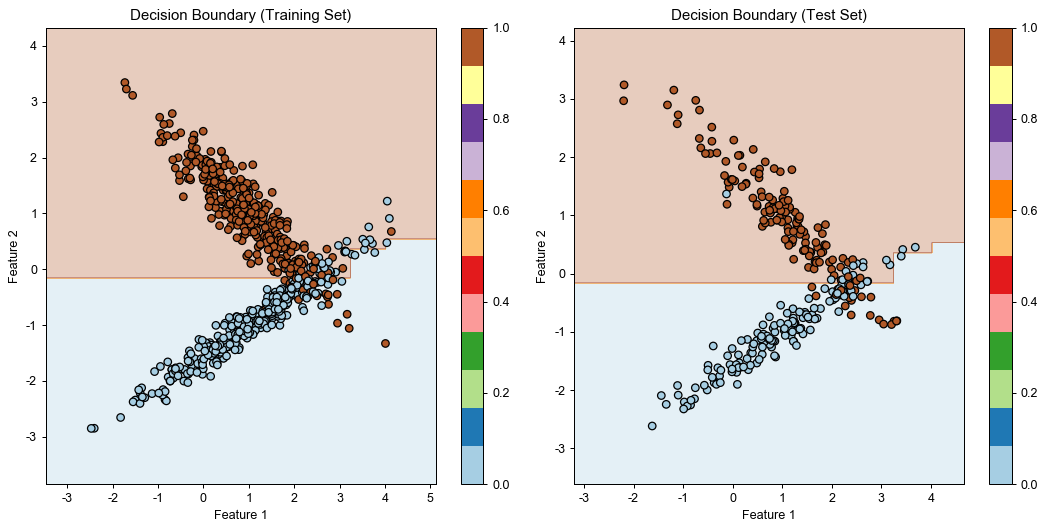

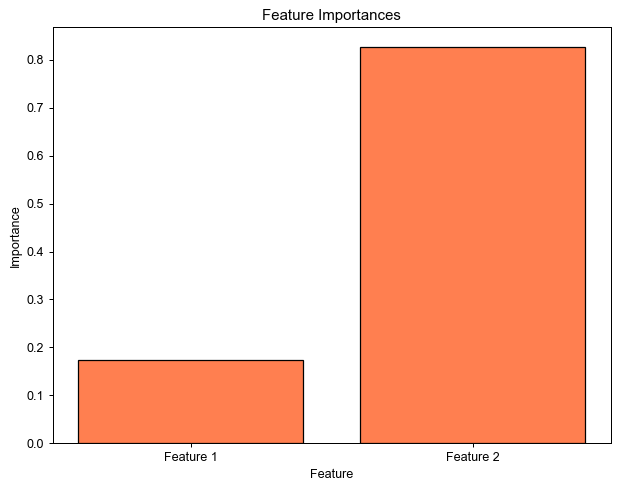

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 生成虚拟数据集
X, y = make_classification(n_samples=1000, n_features=2, n_informative=2, n_redundant=0, n_clusters_per_class=1, random_state=42)

# 分割数据集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 创建和训练AdaBoost模型
base_classifier = DecisionTreeClassifier(max_depth=1)
ada_boost = AdaBoostClassifier(base_classifier, n_estimators=50, random_state=42)
ada_boost.fit(X_train, y_train)

# 预测结果
y_pred = ada_boost.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# 绘制决策边界
def plot_decision_boundary(clf, X, y, title):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.colorbar()

# 绘制训练数据和预测结果的决策边界
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plot_decision_boundary(ada_boost, X_train, y_train, 'Decision Boundary (Training Set)')

plt.subplot(1, 2, 2)
plot_decision_boundary(ada_boost, X_test, y_test, 'Decision Boundary (Test Set)')

plt.tight_layout()
plt.show()

# 绘制特征重要性图
feature_importances = ada_boost.feature_importances_
plt.figure(figsize=(8, 6))
plt.bar(range(len(feature_importances)), feature_importances, color='coral', edgecolor='black')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.title('Feature Importances')
plt.xticks(range(len(feature_importances)), ['Feature 1', 'Feature 2'])
plt.show()

### 核心逻辑

**1. 生成虚拟数据集**：使用 `make_classification` 函数生成一个具有两个特征的虚拟数据集，适合二分类任务。

**2. 训练数据集**：使用 `train_test_split` 将数据分为训练集和测试集。使用 `AdaBoostClassifier` 和决策树桩作为基分类器进行训练。

**3. 预测和准确率**：对测试集进行预测并计算准确率。

**4. 绘制决策边界**：`plot_decision_boundary` 函数绘制模型的决策边界，并用不同颜色显示分类结果。在两个子图中显示训练集和测试集的决策边界。

**5. 特征重要性图**：使用 `feature_importances_` 属性绘制特征重要性图，显示每个特征对最终模型的贡献。

**决策边界图**：左图显示了训练集的决策边界，右图显示了测试集的决策边界。背景颜色表示不同的类别区域，点表示样本数据。

![原文参考图，当前结果见代码输出](attachments/img_037.png)

**特征重要性图**：展示了两个特征的相对重要性，用条形图表示。

![原文参考图，当前结果见代码输出](attachments/img_038.png)

## 应用场景

### Boosting算法适用问题

**1. 问题类型：**

- **分类问题**：Boosting算法主要用于二分类和多分类问题。它通过逐步修正模型的错误来提高分类准确率。
- **回归问题**：虽然Boosting算法的经典应用是分类，但它也可以用于回归问题，通常称为“Boosting回归”。例如，AdaBoost和Gradient Boosting都有回归版本。

**2. 适用情况：**

- **数据量较大**：当有足够多的训练数据时，Boosting能够发挥其优势，因为它需要通过多轮迭代来进行模型训练。
- **数据噪声较小**：Boosting对噪声数据的敏感性较高，噪声过多可能导致过拟合。
- **特征与目标之间的关系复杂**：Boosting通过组合多个弱分类器来捕捉复杂的特征与目标之间的关系。

### 优缺点

**优点：**

1. **高准确率**：Boosting通常能显著提高分类器的准确率，特别是与其他简单模型相比。
2. **适应性强**：能够自动聚焦于之前分类错误的样本，改进分类器的性能。
3. **灵活性**：可以与各种弱分类器（如决策树、线性模型）结合使用。

**缺点：**

1. **计算开销大**：由于需要训练多个弱分类器，计算时间和资源开销较大。
2. **容易过拟合**：特别是在训练数据噪声较多时，Boosting可能会过拟合。
3. **对参数敏感**：模型性能对参数设置（如学习率、迭代次数）较为敏感，需要调参。

### 运用时的前提条件

1. **数据质量**：数据应尽量干净且标记准确。如果数据噪声过多，Boosting算法容易过拟合。
2. **特征工程**：特征应进行适当的预处理和选择，以便模型能够有效地从中学习。
3. **计算资源**：需要足够的计算资源来处理大量的训练迭代和模型训练过程。
4. **合理调参**：对Boosting模型的参数（如学习率、弱分类器的数量）进行合理调参，以避免过拟合或欠拟合。

### 实际应用案例

1. **金融领域**：**信用评分**：Boosting算法常用于信用评分模型，以预测借款人是否会违约。通过考虑历史数据中的复杂模式和关系，提高模型的准确性。
2. **医疗领域**：**疾病预测**：在癌症预测和诊断中，Boosting算法用于分析患者的医疗记录和检测结果，帮助预测是否患有某种疾病。
3. **广告点击率预测**：**在线广告**：在广告点击率预测中，Boosting算法可以用来提高模型对用户点击行为的预测准确率，从而优化广告投放策略。
4. **自然语言处理**：**垃圾邮件检测**：Boosting算法用于识别垃圾邮件，结合不同特征和模式来提高分类精度。

这些应用案例展示了Boosting算法在实际问题中如何通过改进模型的准确性和鲁棒性来带来实质性好处。